## MODE FITS - TEST DIFFERENT FITS

In [36]:
from itertools import product

In [37]:
from specparam import SpectralModel
from specparam.sim import gen_freqs, sim_power_spectrum
from specparam.plts import plot_spectra
from specparam.sim.utils import set_random_seed
from specparam.modes.definitions import *

In [38]:
set_random_seed(191)

In [49]:
# Define simulation settings
AP_PARAMS = {
    'fixed' : [1, 0.75],
    'knee' : [0, 1000, 1.5],
    'doublexp' : [0, 0.15, 900, 1.25],
}

PE_PARAMS = {
    'gaussian' : [10, 0.25, 1, 20, 0.15, 2],
    'cauchy' : [10, 0.25, 1, 20, 0.15, 2],
    'skewed_gaussian' : [10, 0.25, 1, 5, 20, 0.15, 2, 7.5],
    'triangle' : [10, 0.25, 2, 25, 0.15, 4],
    #'gamma' : [X, X, X, X],
}

nlv = 0.001

In [59]:
# Define algorithm settings
model_settings = {'min_peak_height' : 0.1, 'max_n_peaks' : 6, 'peak_width_limits' : [0.5, 12]}

In [60]:
# Generate combinations of all modes
mode_samples = product(*[list(AP_MODES.keys()), list(PE_MODES.keys())])

SIMULATED - AP: fixed, PE: triangle
                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
              Model was fit to the 1-175 Hz frequency range with 0.50 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, exponent)                                        
                                          1.0156, 0.7574                                          
                                                                         

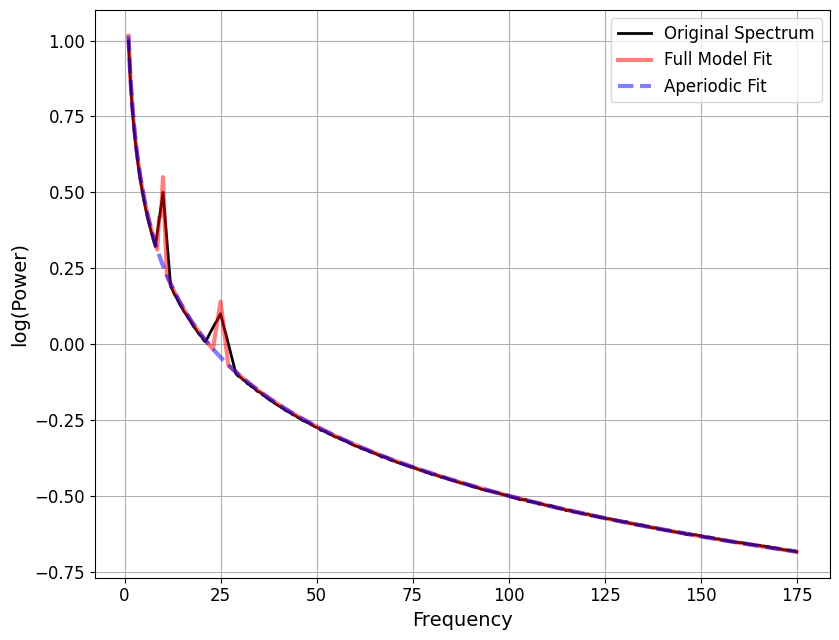

In [64]:
c_ap_mode, c_pe_mode = next(mode_samples)
print('SIMULATED - AP: {}, PE: {}'.format(c_ap_mode, c_pe_mode))
freqs, powers = sim_power_spectrum(\
    [1, 175], {c_ap_mode : AP_PARAMS[c_ap_mode]}, {c_pe_mode : PE_PARAMS[c_pe_mode]}, nlv)
fm = SpectralModel(aperiodic_mode=c_ap_mode, periodic_mode=c_pe_mode, 
                   **model_settings, verbose=False)
fm.report(freqs, powers, plt_log=False)

## SIMS

In [ ]:
# for ap_mode in AP_MODES:
#     for pe_mode in PE_MODES:
        
#         freqs, powers = sim_power_spectrum(\
#             [1, 150], {ap_mode : AP_PARAMS[ap_mode]}, {pe_mode : PE_PARAMS[pe_mode]}, nlv)
#         plot_spectra(freqs, powers, log_freqs=True, log_powers=True,
#                      title='AP: {} - PE: {}'.format(ap_mode, pe_mode))

## MODELS

In [ ]:
# for ap_mode in AP_MODES:
#     for pe_mode in PE_MODES:
        
#         freqs, powers = sim_power_spectrum(\
#             [3, 50], {ap_mode : AP_PARAMS[ap_mode]}, {pe_mode : PE_PARAMS[pe_mode]}, nlv)
        
#         fm = SpectralModel(aperiodic_mode=ap_mode, periodic_mode=pe_mode, verbose=False)
#         fm.report(freqs, powers, plt_log=True)